In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/indian-automobile-nse-data/stat_arb_data.csv


# Johannsen on the one triplet I intuitively believe in 

* ASHOKLEY.NS
* EICHERMOT.NS
* MARUTI.NS

In [3]:
prices = pd.read_csv("/kaggle/input/indian-automobile-nse-data/stat_arb_data.csv")

In [4]:
prices.head()

,Date,ASHOKLEY.NS,BAJAJ-AUTO.NS,EICHERMOT.NS,HEROMOTOCO.NS,M&M.NS,MARUTI.NS,TVSMOTOR.NS
0,2021-01-04,3.862056,8.032787,7.836744,7.848199,6.571777,8.906823,6.180565
1,2021-01-05,3.868761,8.024291,7.843948,7.855841,6.559690,8.900722,6.172967
2,2021-01-06,3.872097,8.015679,7.832839,7.861157,6.554271,8.897209,6.165721
3,2021-01-07,3.927165,8.008506,7.834520,7.851937,6.565483,8.888976,6.188306
4,2021-01-08,3.942801,8.034688,7.875574,7.885996,6.599944,8.946607,6.216056


In [8]:
X = prices[['ASHOKLEY.NS', 'EICHERMOT.NS', 'MARUTI.NS']]

In [40]:
#johannsen test, with det_order 1
from statsmodels.tsa.vector_ar.vecm import coint_johansen

result = coint_johansen(X, det_order=1, k_ar_diff=1)

In [12]:
#determining rank
trace_stat = result.lr1
crit_vals = result.cvt[:, 1]  # 95% column

pd.DataFrame({
    'trace_stat': trace_stat,
    'crit_95%': crit_vals
}, index=['r=0', 'r<=1', 'r<=2'])


,trace_stat,crit_95%
r=0,48.055210,35.0116
r<=1,23.994306,18.3985
r<=2,8.156368,3.8415


welp, it appears rank is 3. I'mma test the p values again to check

In [13]:
from statsmodels.tsa.stattools import adfuller

for col in X.columns:
    stat, pval, *_ = adfuller(X[col])
    print(col, pval)

ASHOKLEY.NS 0.9563822381197067
EICHERMOT.NS 0.9604153617644134
MARUTI.NS 0.940260297045146


All p values are >0.05; so Johannsen is applicable. I'mma try with det_order 0

In [16]:
result_2 = coint_johansen(X, det_order=0, k_ar_diff=1)
trace_stat_2 = result_2.lr1
crit_vals_2 = result_2.cvt[:, 1]  # 95% column

pd.DataFrame({
    'trace_stat': trace_stat_2,
    'crit_95%': crit_vals_2
}, index=['r=0', 'r<=1', 'r<=2'])

,trace_stat,crit_95%
r=0,35.699590,29.7961
r<=1,15.136357,15.4943
r<=2,0.081091,3.8415


yayayayya, rank is now 1

In [17]:
#Extracting co-integrating vector
beta = result_2.evec[:, 0]
beta = beta / beta[0]   # normalize
beta

array([ 1.        , -0.75819453, -0.27951965])

<Axes: title={'center': 'Johansen Cointegrated Spread'}>

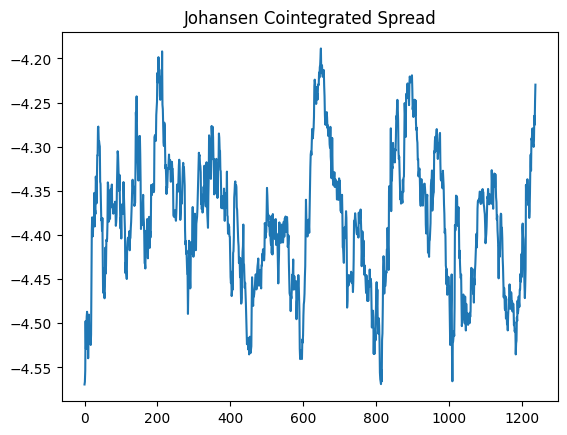

In [18]:
#constructing spread
spread = X @ beta
spread.plot(title="Johansen Cointegrated Spread")

In [19]:
from statsmodels.tsa.stattools import adfuller
adfuller(spread)

(-4.456960310262353,
 0.00023501689880890523,
 0,
 1238,
 {'1%': -3.4356431428057386,
  '5%': -2.8638774363142963,
  '10%': -2.568014482215048},
 -6276.355809271909)

In [22]:
import statsmodels.api as sm
import numpy as np

spread_lag = spread.shift(1).dropna()
delta_spread = spread.diff().dropna()

reg = sm.OLS(delta_spread, sm.add_constant(spread_lag)).fit()
alpha = reg.params.iloc[1]

half_life = -np.log(2) / alpha
half_life

22.437169871820526

In [25]:
#Normalizing the spread
lookback = int(half_life)
z = (spread - spread.rolling(lookback).mean()) / spread.rolling(lookback).std()

In [26]:
print(z)

0            NaN
1            NaN
2            NaN
3            NaN
4            NaN
          ...   
1234    1.102258
1235    1.690579
1236    1.271500
1237    1.774980
1238    1.923381
Length: 1239, dtype: float64


In [30]:
entry_z = 2.0
exit_z = 0.5

position = pd.Series(0, index=z.index)

for t in range(1, len(z)):
    if position.iloc[t-1] == 0:
        if z.iloc[t] < -entry_z:
            position.iloc[t] = 1     # long spread
        elif z.iloc[t] > entry_z:
            position.iloc[t] = -1    # short spread
    elif position.iloc[t-1] == 1:
        position.iloc[t] = 0 if z.iloc[t] > -exit_z else 1
    elif position.iloc[t-1] == -1:
        position.iloc[t] = 0 if z.iloc[t] < exit_z else -1

In [31]:
beta = beta / np.sum(np.abs(beta))  # normalize exposure

asset_positions = pd.DataFrame(
    index=X.index,
    columns=X.columns
)

for i, col in enumerate(X.columns):
    asset_positions[col] = position * beta[i]

In [32]:
log_returns = X.diff().dropna()

aligned_pos = asset_positions.shift(1).loc[log_returns.index]

pnl = (aligned_pos * log_returns).sum(axis=1)

In [33]:
cost_per_leg = 0.001  # 10 bps

turnover = asset_positions.diff().abs().sum(axis=1)
transaction_costs = cost_per_leg * turnover

pnl_net = pnl - transaction_costs.loc[pnl.index]

In [34]:
import numpy as np

cum_pnl = pnl_net.cumsum()

sharpe = np.sqrt(252) * pnl_net.mean() / pnl_net.std()
max_dd = (cum_pnl - cum_pnl.cummax()).min()

print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_dd:.2f}")

Sharpe Ratio: 0.10
Max Drawdown: -0.13


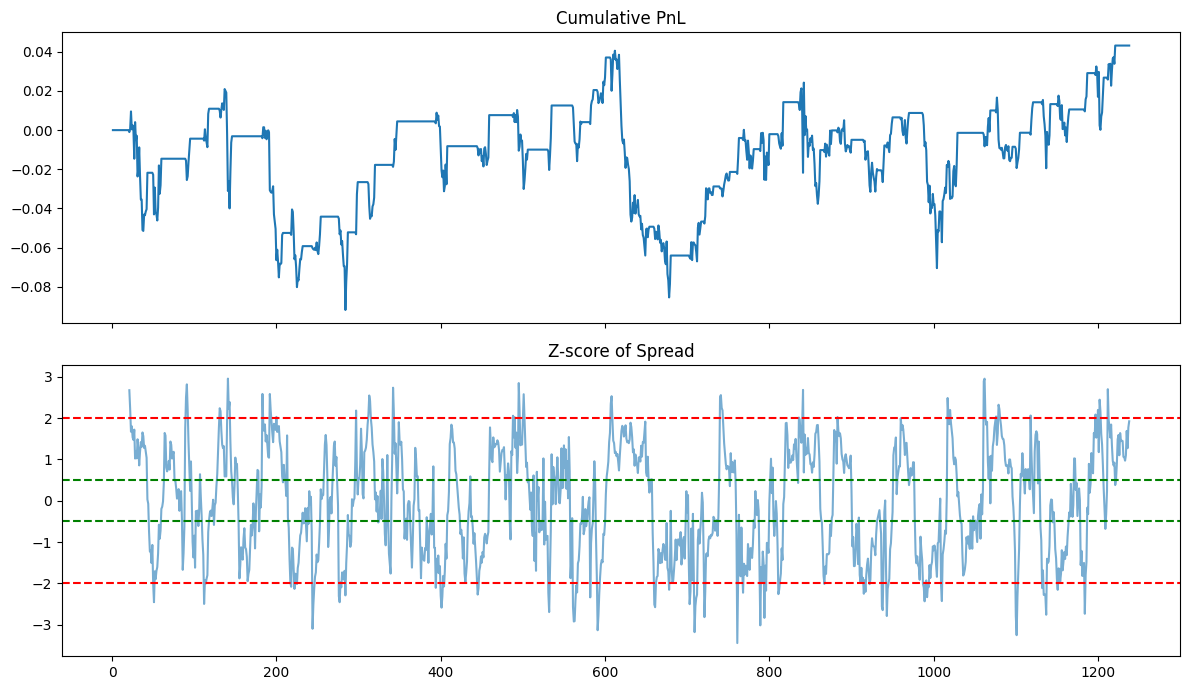

In [36]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

cum_pnl.plot(ax=ax[0], title="Cumulative PnL")
z.plot(ax=ax[1], title="Z-score of Spread", alpha=0.6)
ax[1].axhline(entry_z, color='r', linestyle='--')
ax[1].axhline(-entry_z, color='r', linestyle='--')
ax[1].axhline(exit_z, color='g', linestyle='--')
ax[1].axhline(-exit_z, color='g', linestyle='--')

plt.tight_layout()
plt.show()

## Gonna add volatility targeting here

In [37]:
target_vol = 0.01  # 1% daily
realized_vol = pnl_net.rolling(60).std()

scaler = target_vol / realized_vol
pnl_scaled = pnl_net * scaler.shift(1)

In [38]:
cum_pnl_vt = pnl_scaled.cumsum()
sharpe_vt = np.sqrt(252) * pnl_scaled.mean() / pnl_scaled.std()
max_dd_vt = (cum_pnl_vt - cum_pnl_vt.cummax()).min()

print(f"Vol-Targeted Sharpe: {sharpe_vt:.2f}")
print(f"Vol-Targeted Max DD: {max_dd_vt:.2f}")

Vol-Targeted Sharpe: -0.02
Vol-Targeted Max DD: -0.27


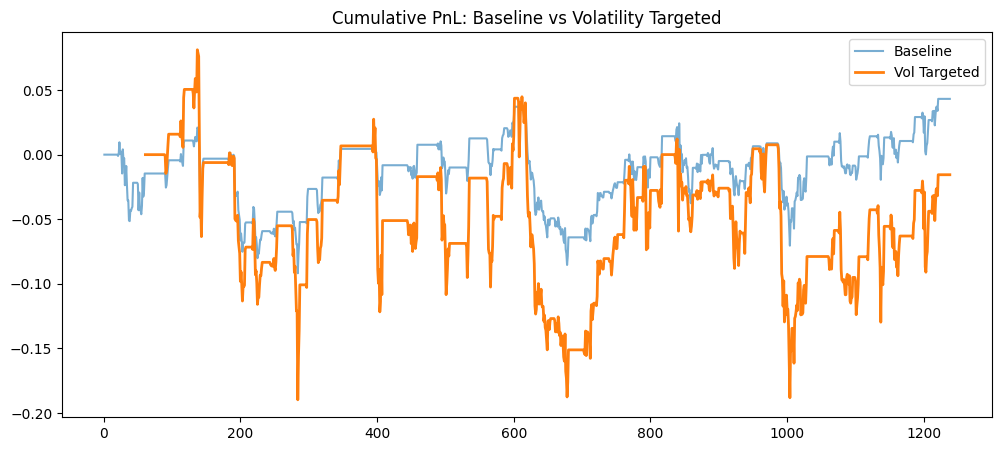

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
cum_pnl.plot(label="Baseline", alpha=0.6)
cum_pnl_vt.plot(label="Vol Targeted", linewidth=2)
plt.legend()
plt.title("Cumulative PnL: Baseline vs Volatility Targeted")
plt.show()